In [1]:
#EDA Exploratory data analysis
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df=pd.read_csv('..//data/creditcard.csv')

In [3]:
#check 5 rows
print(df.head())

#check shape
print('Shape:', df.shape)

#check for missing values
print('Missing Values:', df.isnull().sum())

#check class distribution
print('Class distribution:\n',df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

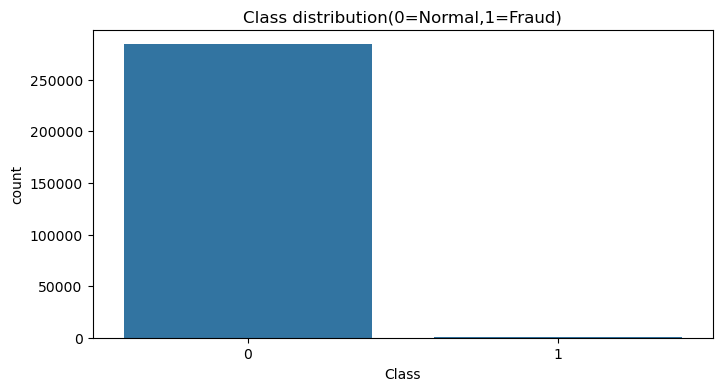

In [4]:

#visualize class imbalance
plt.figure(figsize=(8,4))
sns.countplot(x='Class',data=df)
plt.title('Class distribution(0=Normal,1=Fraud)')
plt.show()


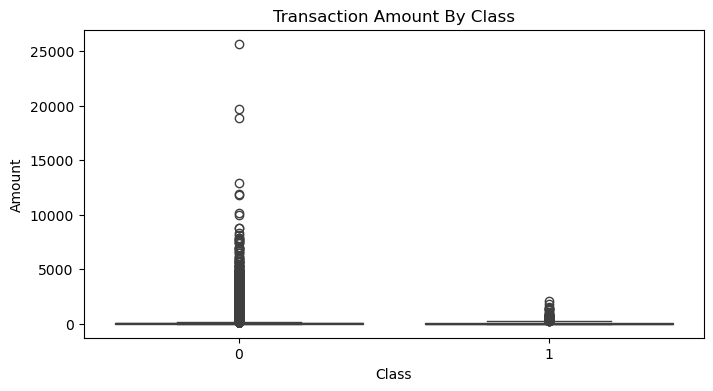

In [5]:
#Check transaction amount by class
plt.figure(figsize=(8,4))
sns.boxplot(x='Class',y='Amount',data=df)
plt.title('Transaction Amount By Class')
plt.show()

In [6]:
#preprocessing
#import preprocessing libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


In [7]:
#scale the amount column
scaler=StandardScaler()
df['Amount_scaled']=scaler.fit_transform(df[['Amount']])
#drop original amount and time column
df=df.drop(['Amount','Time'],axis=1)

In [8]:
#seperate feautures and target
X=df.drop('Class',axis=1)
y=df['Class']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print('Training size:', X_train.shape)
print('Testing_size:', X_test.shape)

Training size: (227845, 29)
Testing_size: (56962, 29)


In [10]:
#let us handle imbalance with SMOTE
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)
print('After SMOTE:')
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [13]:
#Building the models split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [15]:
#Logistic Regression
lr_model=LogisticRegression(random_state=42)
lr_model.fit(X_train_sm,y_train_sm)
print('Logistic Regression Trained:')

Logistic Regression Trained:


In [16]:
#Random Forest
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
print('Random Forest Trained:')

Random Forest Trained:


In [18]:
#XGBoost
xgb_model=XGBClassifier(random_state=42)
xgb_model.fit(X_train,y_train)
print('XGBoost Trained:')

XGBoost Trained:


In [19]:
#Now we evaluate the models:
#import evaluation libraries
from sklearn.metrics import classification_report,confusion_matrix

In [20]:
#Evaluate Logistic Regression
lr_pred=lr_model.predict(X_test)
print('Logistic Regression Results:')
print(classification_report(y_test,lr_pred))
print(confusion_matrix(y_test,lr_pred))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

[[55355  1509]
 [    8    90]]


In [21]:
#Evaluate Random Forest
rf_pred=rf_model.predict(X_test)
print('Random Forest Results:')
print(classification_report(y_test,rf_pred))
print(confusion_matrix(y_test,rf_pred))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   17    81]]


In [23]:
#Evaluate XGBoost
xgb_pred=xgb_model.predict(X_test)
print('XGBoost Results:')
print(classification_report(y_test,xgb_pred))
print(confusion_matrix(y_test,xgb_pred))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56853    11]
 [   20    78]]


In [25]:
import joblib

joblib.dump(rf_model, '..//models/fraud_model.pkl')
print("Model saved!")

Model saved!
